# Onset-HFO 4 — The agent drives the analysis, and a model learns from the cohort

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/berdakh/onset-hfo/blob/master/onset-hfo/notebooks/04_orchestration_and_localization.ipynb)

Notebooks 1–3 cover a **fixed pipeline** and an agent that can *read* what it
produced. This one covers the two halves added since: an agent that decides
*what to measure*, and a learned per-contact model with calibrated
uncertainty — plus the place where they meet.

**Nothing here downloads a recording.** The orchestration runs on simulated
data and the modelling runs on a cohort feature table committed to the
repository (269 KB), so the whole notebook executes in a free Colab instance
in a couple of minutes.

| part | what it shows |
|---|---|
| A | the agent re-running a detector at a stricter threshold — and changing its mind |
| B | every claim resolving to a run id, or being struck |
| C | a learned model, and the gap between subject-specific and deployable |
| D | calibration, and a conformal guarantee that does not survive a new patient |
| E | the coupling: the model as a tool the planner stops on |
| F | trying to break the whole thing |

**Read the honest summary first.** The learned model barely beats the ripple
rate it was built from. The interesting numbers here are gaps and failures,
not scores.

In [1]:
# Colab setup. On your own machine, skip this cell and run
#   pip install -e ".[dev,ml]"  from the onset-hfo directory instead.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
REPO = "https://github.com/berdakh/onset-hfo.git"
BRANCH = "master"   # change to the default branch once this work is merged

if IN_COLAB and not os.path.exists("onset-hfo"):
    subprocess.run(["git", "clone", "-q", "--branch", BRANCH, "--depth", "1", REPO], check=True)
if IN_COLAB:
    os.chdir("/content/onset-hfo/onset-hfo")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[ml]"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
sys.path.insert(0, os.getcwd())
print("working directory:", os.getcwd())

working directory: /home/user/onset-hfo/onset-hfo


---
## Part A — the agent chooses the analysis

The original agent had eight read-only tools over a *saved* analysis. It could
report that a channel had 54 ripples/min at a threshold somebody chose hours
ago. It could not ask the question a reviewer asks next:

> *Does that survive a stricter threshold?*

Every tool below executes the real pipeline at parameters the planner picks at
call time. Let's watch it happen.

In [2]:
from onset_hfo.synthetic import make_synthetic_recording
from onset_agent.analysis import AnalysisSession, build_registry

recording = make_synthetic_recording(seed=7, duration_s=30, verbose=False)
session = AnalysisSession(recording)
tools = build_registry(session)

print("tools the planner may call:")
for name in tools.names():
    print("  -", name)

tools the planner may call:
  - get_recording_metadata
  - channel_qc
  - detect_hfo
  - detect_spikes
  - spectral_power
  - rate_change
  - compare_detectors
  - propagation_lead
  - estimate_soz_probability
  - get_event_evidence


### The worked example: survey, then challenge

A survey at the conventional 5 robust SD, then a re-test of the leader at 7.
Note the timing: the survey pays for the band-pass, the re-test is nearly
free, which is what makes re-planning practical rather than theoretical.

In [3]:
survey = tools.run("detect_hfo", {"detector": "rms", "threshold_sd": 5, "k": 4})
leader = next(iter(survey.output["channels"]))
print(f"[{survey.run_id}] survey at 5 SD  ({survey.runtime_s:.2f} s)")
for ch, row in survey.output["channels"].items():
    print(f"    {ch:10s} {row['rate_per_min']:6.1f}/min   CI {row['rate_ci']}")

retest = tools.run("detect_hfo", {"channels": [leader], "threshold_sd": 7, "k": 4})
after = retest.output["channels"][leader]["rate_per_min"]
before = survey.output["channels"][leader]["rate_per_min"]
print(f"\n[{retest.run_id}] {leader} re-tested at 7 SD  ({retest.runtime_s:.2f} s)")
print(f"    {before:.1f}/min  ->  {after:.1f}/min   (survives {after / before:.0%})")

[hfo_001] survey at 5 SD  (0.46 s)
    SA2-SA3      54.0/min   CI [35.46, 76.38]
    SA1-SA2      36.0/min   CI [21.17, 54.67]
    SA3-SA4      24.0/min   CI [12.2, 39.64]
    SB2-SB3       6.0/min   CI [0.85, 14.99]

[hfo_002] SA2-SA3 re-tested at 7 SD  (0.04 s)
    54.0/min  ->  30.0/min   (survives 56%)


### Does the extra control change the answer?

Four rungs, the **same analyzers**, the same recording. Only who decides what
runs changes:

- **S0** a fixed sequence of calls, no model at all — the prior-work baseline
- **S1** the model picks the analyses once, never sees the results
- **S2** the model sees each result before choosing the next call
- **S3** as S2, plus every claim must resolve to a run id

A channel's score is its survey rate multiplied by how well that rate survived
any stricter threshold, capped at 1 — scrutiny can lower confidence, never
raise it. S0 and S1 never re-test, so they cannot produce a robustness below
1. That is the mechanism by which orchestration can change the answer at all.

In [4]:
from onset_agent.planner import Rung, run_rung, ModelJudged

for rung in [Rung.S0, Rung.S1, Rung.S2, Rung.S3]:
    session.reset_memo()          # each rung pays for its own detections
    result = run_rung(session, rung, stop_rule=ModelJudged(max_calls=12), max_steps=12)
    top = [(r.channel, round(r.score, 1), round(r.robustness, 2)) for r in result.ranking[:3]]
    print(f"{rung.value}: {result.cost['n_tool_calls']:2d} calls, "
          f"{result.n_retested} channel(s) challenged")
    print(f"     top-3 (channel, score, robustness): {top}")

S0:  5 calls, 0 channel(s) challenged
     top-3 (channel, score, robustness): [('SA2-SA3', 54.0, 1.0), ('SA1-SA2', 36.0, 1.0), ('SA3-SA4', 24.0, 1.0)]


S1:  5 calls, 0 channel(s) challenged
     top-3 (channel, score, robustness): [('SA2-SA3', 54.0, 1.0), ('SA1-SA2', 36.0, 1.0), ('SA3-SA4', 24.0, 1.0)]


S2:  8 calls, 2 channel(s) challenged
     top-3 (channel, score, robustness): [('SA2-SA3', 30.0, 0.56), ('SA1-SA2', 26.0, 0.72), ('SA3-SA4', 24.0, 1.0)]


S3:  8 calls, 2 channel(s) challenged
     top-3 (channel, score, robustness): [('SA2-SA3', 30.0, 0.56), ('SA1-SA2', 26.0, 0.72), ('SA3-SA4', 24.0, 1.0)]


Read the `robustness` column. The re-planning rungs demote a channel whose
rate collapses under a stricter threshold; the fixed rungs cannot, because
they never look again.

**A caution the repository insists on.** On the real `sub-pt01` recording this
same mechanism re-orders the top five and the re-ordering *means nothing* —
those channels sit between 70 and 83 events/min with heavily overlapping
intervals, so they are tied, not ranked. A mechanism that works is not the
same as a mechanism that helped.

---
## Part B — every number resolves to a run, or it is struck

The evidence store is an append-only ledger of every tool call. A sentence
stating a number is admissible only if some tool produced it.

In [5]:
from onset_agent.verifier import DeterministicVerifier

session.reset_memo()
result = run_rung(session, Rung.S3, stop_rule=ModelJudged(max_calls=10))
store = result.store

print(f"{len(store)} tool runs recorded\n")
print(store.digest(max_runs=3, per_run_chars=110))
print("\nwhere did 54.0 come from? ->", store.find_number(54.0))
print("where did 99999 come from? ->", store.find_number(99999) or "nowhere: unsupported")

8 tool runs recorded

8 tool run(s) so far (showing the last 3):
[compare_001] compare_detectors() -> {"window_s": [0.0, 30.0], "agreement": {"detector_a": "rms", "detector_b": "line_length", "n_rms": 75, "n_line... (truncated; call again for detail)
[soz_001] estimate_soz_probability(k=10) -> FAILED: no learned SOZ model is attached to this session. Fit one with onset_hfo.models.fit_soz_model on a cohort, then pass it to AnalysisSession(..., soz_model=model). The other tools work without it.
[evidence_001] get_event_evidence(channel=SA2-SA3, k=3) -> {"channel": "SA2-SA3", "detector": "rms", "window_s": [0.0, 30.0], "n_accepted_on_channel": 27, "evidence": [{... (truncated; call again for detail)

where did 54.0 come from? -> ['hfo_001']
where did 99999 come from? -> nowhere: unsupported


In [6]:
honest = result.report
fabricated = honest + " Channel ZZ1-ZZ2 reached 4210.5 ripples/min [hfo_001]."

check = DeterministicVerifier()(fabricated, store)
print(f"claims checked: {check.n_claims}   struck: {check.n_struck}")
for struck in check.struck:
    print("  STRUCK:", struck["sentence"])
    print("  reason:", struck["reason"])
print("\nprovenance coverage of what survived:", round(check.provenance_coverage, 3))

claims checked: 4   struck: 1
  STRUCK: Channel ZZ1-ZZ2 reached 4210.5 ripples/min [hfo_001].
  reason: no tool run produced 4210.5

provenance coverage of what survived: 0.75


The research question is not whether verification removes hallucinations — it
does, by construction. It is what verification **costs**, because a verifier
also strikes true statements it cannot resolve. `compare_verifiers` runs both
the arithmetic checker and a language-model checker and reports the
off-diagonal cells: true statements the model removed, and fabrications it let
through.

---
## Part C — a learned per-contact model

Everything above ranks channels by a threshold. Can a model trained on the
cohort do better?

The cohort: **22 subjects, 1466 channels, 301 labelled seizure-onset contacts**
from the archive's own clinical spreadsheet. The table is committed, so this
runs with no download.

In [7]:
import pandas as pd
from onset_hfo.learn import SHIPPED_COHORT

features = pd.read_csv(SHIPPED_COHORT / "features.csv.gz")
print(f"{features['subject'].nunique()} subjects, {len(features)} channels, "
      f"{int(features['is_soz'].sum())} labelled SOZ "
      f"({features['is_soz'].mean():.1%} prevalence)")
features.groupby("site").agg(subjects=("subject", "nunique"),
                             channels=("channel", "size"), soz=("is_soz", "sum"))

22 subjects, 1466 channels, 301 labelled SOZ (20.5% prevalence)


,subjects,channels,soz
site,,,
JHH,6,519,68
NIH,13,790,174
UMF,1,73,33
UMMC,2,84,26


### Three protocols, and the gap between them is the result

| protocol | trains on | answers |
|---|---|---|
| **within-subject** | other contacts of the *same* patient | are the contacts separable at all? a **ceiling** |
| **leave-one-patient-out** | every *other* patient | the deployable number |
| **leave-one-site-out** | patients at the *other* hospitals | what survives a change of centre |

Within-subject is an upper bound, **not a deployable model**: using it would
require already knowing some of that patient's answer.

Class imbalance is severe, so AUPRC against the prevalence baseline is the
number to read — accuracy is meaningless and AUROC is optimistic.

In [8]:
from onset_hfo.models import evaluate, baseline_scores

rows = [baseline_scores(features, col, "raw").summary()
        for col in ["rms_rate_per_min", "ll_rate_per_min"]]
for protocol in ["within_subject", "lopo", "loso"]:
    rows.append(evaluate(features, "gradient_boosting", "raw", protocol).summary())

table = pd.DataFrame(rows)[["protocol", "model", "prevalence", "auprc",
                            "auprc_lift_over_prevalence", "auroc", "precision_at_5"]]
table

,protocol,model,prevalence,auprc,auprc_lift_over_prevalence,auroc,precision_at_5
0,none,baseline:rms_rate_per_min,0.2053,0.4467,2.176,0.7178,0.4727
1,none,baseline:ll_rate_per_min,0.2053,0.4674,2.276,0.7208,0.5091
2,within_subject,gradient_boosting,0.2053,0.7088,3.452,0.9014,0.6364
3,lopo,gradient_boosting,0.2053,0.4802,2.339,0.7349,0.5545
4,loso,gradient_boosting,0.2053,0.4763,2.320,0.7047,0.5364


**Read the gap, not the best row.**

The learned model buys about one AUPRC point over simply ranking channels by
line-length rate — thirteen features and a cross-validation harness for almost
nothing. The within-subject ceiling is far above both: the features *are*
separable inside a recording, and most of that does not survive the move to a
new patient. Cross-site costs almost nothing on top of cross-patient, which
puts the transfer problem at the patient level rather than the hospital level.

### So how much does a clinician's handful of labels buy?

The ceiling needs labels you do not have. But a reviewer looking at a new
implantation can genuinely point at a few contacts. Below, the target patient
contributes *k* labelled contacts chosen **before anything is predicted**, and
the model is scored only on the contacts it was *not* given. At `k = 0` this
is exactly leave-one-patient-out, so both ends of the curve are the same
experiment.

In [9]:
from onset_hfo.models import label_budget_curve

curve = label_budget_curve(features, budgets=(0, 2, 5, 10, 20), model="logistic",
                           normalisation="raw", n_repeats=3)
curve[["n_labels", "labelled_fraction", "auprc", "gap_closed", "precision_at_5"]]

,n_labels,labelled_fraction,auprc,gap_closed,precision_at_5
0,0,0.000,0.4551,0.000,0.5727
1,2,0.030,0.4828,0.139,0.6091
2,5,0.075,0.5046,0.248,0.5818
3,10,0.150,0.5656,0.553,0.5818
4,20,0.301,0.6090,0.770,0.6364


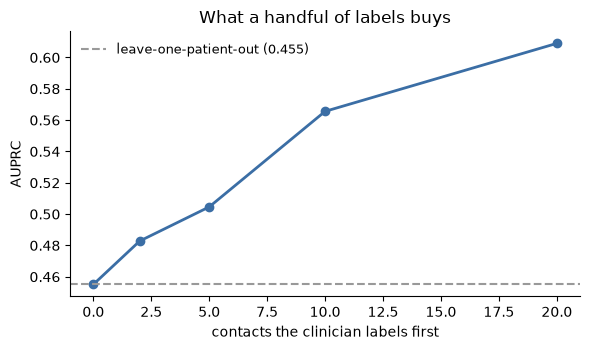

In [10]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(curve["n_labels"], curve["auprc"], "o-", color="#3b6ea5", lw=2)
ax.axhline(curve["auprc"].iloc[0], ls="--", c="#999",
           label=f"leave-one-patient-out ({curve['auprc'].iloc[0]:.3f})")
ax.set_xlabel("contacts the clinician labels first")
ax.set_ylabel("AUPRC")
ax.set_title("What a handful of labels buys")
ax.legend(frameon=False, fontsize=9)
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()

Five contacts — under a tenth of a typical implantation — recovers a large
part of what is lost moving to a new patient. `labelled_fraction` is in the
table on purpose: *40 labels* sounds modest until it is 60% of the electrodes.

---
## Part D — calibrated probabilities, and a guarantee that breaks

A ranking is not enough to act on. "These contacts, ranked" invites the reader
to draw their own line; "these six contacts, with 90% coverage" is a statement
with a guarantee attached.

Split conformal prediction gives that guarantee **without assuming the model
is right** — it assumes only that calibration and test data are
*exchangeable*. Patients are not.

In [11]:
from onset_hfo.uncertainty import conformal_coverage_report, expected_calibration_error

lopo = evaluate(features, "gradient_boosting", "raw", "lopo")
print("expected calibration error (uncalibrated):",
      round(expected_calibration_error(lopo.scores, lopo.truth), 4))

report = conformal_coverage_report(lopo, alpha=0.1, seed=0)
for key in ["nominal_coverage", "empirical_coverage", "mean_set_size",
            "frac_singleton", "frac_ambiguous", "n_calibration_patients",
            "n_test_patients"]:
    print(f"  {key:24s} {report[key]}")

expected calibration error (uncalibrated): 0.0415
  nominal_coverage         0.9
  empirical_coverage       0.8661
  mean_set_size            1.1232
  frac_singleton           0.8768
  frac_ambiguous           0.1232
  n_calibration_patients   9
  n_test_patients          13


**It undercovers, and that is the finding.** The guarantee does not fail
loudly — it produces tight-looking sets that cover less often than advertised,
because the calibration patients are not exchangeable with the test patients.

The clinically meaningful object is one number per patient: how many contacts
**cannot be ruled out**. It is brutal reading.

In [12]:
pd.DataFrame(report["candidate_sets"])[
    ["subject", "n_contacts", "n_candidates", "candidate_fraction",
     "n_true_soz", "n_soz_covered"]]

,subject,n_contacts,n_candidates,candidate_fraction,n_true_soz,n_soz_covered
0,sub-jh101,95,2,0.0211,5,1
1,sub-jh102,94,5,0.0532,2,0
2,sub-jh108,116,11,0.0948,8,2
3,sub-pt10,44,7,0.1591,9,6
4,sub-pt11,70,32,0.4571,23,16
5,sub-pt12,45,0,0.0000,9,0
6,sub-pt14,42,1,0.0238,7,0
7,sub-pt16,37,9,0.2432,6,5
8,sub-pt2,51,7,0.1373,7,1
9,sub-pt3,76,17,0.2237,37,9


A patient whose candidate set is four contacts has an actionable result. A
patient whose set is forty has not been localized, however confident any
individual score looked — and one patient here has a set of zero, having ruled
out every contact including all the true ones.

---
## Part E — the coupling

This is where the two halves meet, and it is deliberately unremarkable: the
learned model is **a tool in the registry like any other**, returning JSON.
The planner does not know how it works. What it consumes is the *width* of the
candidate set — and it keeps gathering evidence while that set is too wide to
act on.

In [13]:
from onset_hfo.models import fit_soz_model
from onset_agent.planner import ConformalWidth

model = fit_soz_model(features, model="logistic", normalisation="raw", alpha=0.1)
print("model trained on", model.n_train_patients, "patients;",
      "conformal quantile", round(model.conformal_quantile, 3))

coupled = AnalysisSession(recording, soz_model=model)
result = run_rung(coupled, Rung.S2, stop_rule=ConformalWidth(max_width=3, max_calls=12))
print("\nstopped because:", result.stop_reason)

soz_runs = result.store.runs("estimate_soz_probability", ok_only=True)
if soz_runs:
    out = soz_runs[-1].output
    print(f"candidate set: {out['candidate_set_size']}/{out['n_channels']} channels "
          f"at {out['nominal_coverage']:.0%} coverage")

model trained on 15 patients; conformal quantile 0.768



stopped because: the conformal candidate set is EMPTY: the model ruled out every channel, which means it is being applied outside the distribution it was calibrated on, not that the recording was localized
candidate set: 0/15 channels at 90% coverage


**Look at why it stopped.** The model was fitted on real ECoG from 22
patients and we have just pointed it at a *simulation* — a different montage,
a different sampling rate, a different everything. It finds neither label
plausible for any channel, so the candidate set comes back **empty**.

An empty set is not a narrow one. Writing this notebook is what surfaced the
bug: the rule originally treated zero candidates as "narrow enough to act on"
and stopped with a message that read like success. It now says what actually
happened. The most obvious failure mode of a deployed model should not be its
success condition.

In [14]:
# Without a model the tool refuses with something the planner can act on,
# and everything else still runs. A missing model degrades the agent; it
# does not break it.
bare = build_registry(AnalysisSession(recording)).run("estimate_soz_probability", {})
print("ok:", bare.ok)
print(bare.error[:200])

ok: False
no learned SOZ model is attached to this session. Fit one with onset_hfo.models.fit_soz_model on a cohort, then pass it to AnalysisSession(..., soz_model=model). The other tools work without it.


---
## Part F — trying to break it

Everything above measures how well something works. These measure whether it
can be made **confidently wrong**. Each test states its expectation before it
runs: a test that can be passed by any outcome is not a test.

In [15]:
from onset_agent.falsify import run_falsification_suite
from onset_hfo.cohort import soz_labels

labels = soz_labels(recording.subject, recording=recording)
for check in run_falsification_suite(recording, labels, repeats=2):
    print(f"[{check.verdict}] {check.name}")
    print(f"        {check.reading}")

[PASS] no pathology
        the system reported that no channel stands out, which is the right answer for a recording with nothing in it
[PASS] anonymised channel names
        the ranking is driven by the signal
[PASS] leading channel removed
        9 surviving channels measured the same rate to within 0.00/min, so rates are per-channel and not contingent on the rest of the montage
[PASS] run-to-run stability
        every run gave the same top-k
[PASS] shuffled name-to-signal mapping
        the SOZ score collapsed to chance when the correspondence was broken, which is what it should do


One of these failed when it was first written. Given a simulation containing
**no epileptic contacts at all**, the pipeline ranked a channel at 6/min and
nothing in its output said the recording was empty. There was no null
hypothesis — every ranking function sorts noise.

The fix was not a threshold. A leader must be distinguishable from the
*median* channel's confidence interval, built from quantities the pipeline
already computed, so it tightens by itself as the window grows. Check that it
discriminates — a null that always fires is worthless:

In [16]:
from onset_hfo.metrics import leader_separation
from onset_hfo.pipeline import run_pipeline

for label, rec in [("with implanted ripples", recording),
                   ("with nothing in it",
                    make_synthetic_recording(seed=3, duration_s=30, hot_leads=0,
                                             verbose=False))]:
    sep = leader_separation(run_pipeline(rec, verbose=False).rates["rms"])
    print(f"{label:24s} leader {sep['leader_rate_per_min']:5.1f}/min  "
          f"median {sep['median_rate_per_min']:4.1f}  "
          f"tied {sep['n_tied_with_leader']}/{sep['n_channels']}  "
          f"-> stands out: {sep['distinguishable']}")

with implanted ripples   leader  54.0/min  median  4.0  tied 3/15  -> stands out: True


with nothing in it       leader   6.0/min  median  2.0  tied 15/15  -> stands out: False


---
## What none of this establishes

- **Every orchestration number above comes from a deterministic scripted
  planner**, not a language model. It is the control, not the result. The
  anonymised-names falsification test exists specifically to catch a model
  reciting priors about electrode naming, and a script cannot fail it.
- **This is ictal data.** The clinical HFO literature measures *interictal*
  rate; every feature here comes from a 60-second window around a seizure.
- **The model is not clinical.** Fitted on 22 recordings from three centres,
  scored against a retrospective record, on patients whose outcome is already
  known.
- **Nothing here identifies a seizure onset zone.** The agent's guard still
  refuses SOZ questions; localization is an offline metric computed by code,
  never a claim the model is allowed to make.

`docs/ORCHESTRATION.md` and `docs/LOCALIZATION.md` carry the full design and
end with explicit "what is not done" sections.